# RAG + Embeddings + Semantic Search 🚀


### Assignment 1 — Traditional Search vs Semantic Search

#### Objective

Understand:

* exact keyword matching
* why semantic search is needed
* limitations of traditional retrieval

In [1]:
documents = [
    "Employees receive annual paid leaves.",
    
    "Automobiles are used for transportation.",
    
    "Health insurance is available for employees.",
    
    "Python is widely used in artificial intelligence.",
    
    "Dogs are loyal domestic animals."
]

queries = [
    "car",
    "vehicle",
    "AI",
    "pet",
    "leave application"
]

for query in queries:

    print(f"\nQuery: {query}")

    found = False

    for doc in documents:

        if query.lower() in doc.lower():

            print("MATCH:", doc)

            found = True

    if not found:

        print("No Match Found")


Query: car
No Match Found

Query: vehicle
No Match Found

Query: AI
MATCH: Employees receive annual paid leaves.
MATCH: Health insurance is available for employees.

Query: pet
No Match Found

Query: leave application
No Match Found


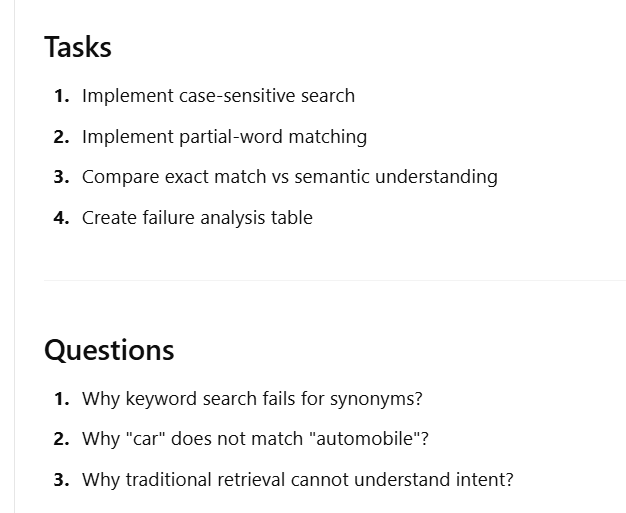

# Assignment 2 — Embedding Generation

#### Objective

Understand:

* embeddings
* vector dimensions
* semantic representation
* embedding models

In [2]:
from sentence_transformers import SentenceTransformer

# -----------------------------
# SENTENCES
# -----------------------------

sentences = [
    "I love cricket.",
    
    "Cricket is my favorite sport.",
    
    "Artificial intelligence is transforming industries.",
    
    "Machine learning improves automation.",
    
    "Pizza tastes delicious."
]

# -----------------------------
# LOAD MODEL
# -----------------------------

model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

# -----------------------------
# GENERATE EMBEDDINGS
# -----------------------------

embeddings = model.encode(sentences)

print("Embedding Shape:")
print(embeddings.shape)

print("\nFirst Embedding Vector:")
print(embeddings[0][:20])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding Shape:
(5, 384)

First Embedding Vector:
[ 0.04998948  0.0459271  -0.005857   -0.06320536  0.03118923  0.01137127
  0.0348446   0.00751416  0.02178711  0.12903433 -0.03877905 -0.10302086
  0.01504307  0.0653824   0.11054195 -0.00782061  0.02247507 -0.09790237
 -0.00697679 -0.07932597]


# Try changing models:

In [ ]:
all-MiniLM-L6-v2
all-mpnet-base-v2
BAAI/bge-small-en

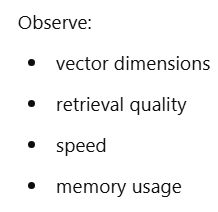

# Multilingual Experiment

In [ ]:
query = "मला क्रिकेट आवडते"

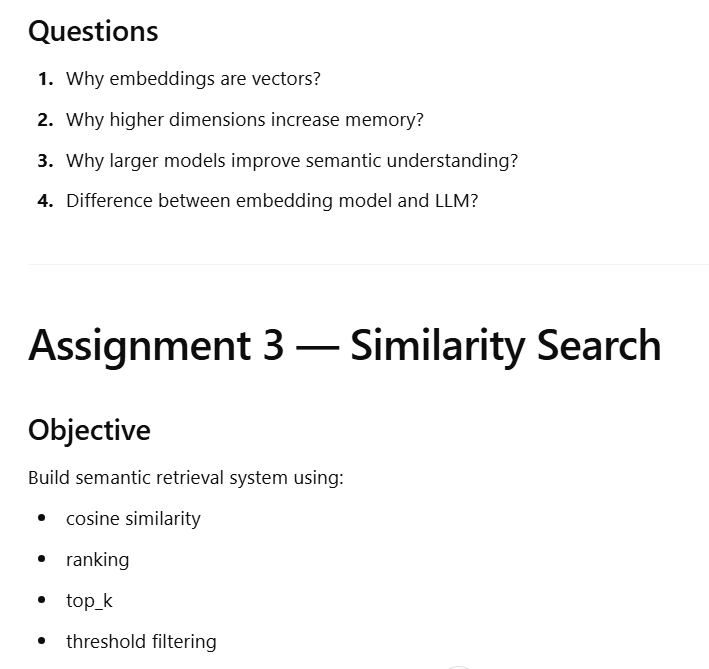

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# DOCUMENTS
# -----------------------------

documents = [
    "Employees receive 20 annual paid leaves.",
    
    "Employees must submit leave requests through the HR portal.",
    
    "Health insurance covers employees and dependents.",
    
    "Travel reimbursement is available for business trips.",
    
    "Employees can work remotely twice a week.",
    
    "Internet expenses are reimbursed for remote employees.",
    
    "Office cafeteria serves lunch daily."
]

query = "How can I apply for leave?"

# -----------------------------
# LOAD MODEL
# -----------------------------

model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

# -----------------------------
# CREATE EMBEDDINGS
# -----------------------------

doc_embeddings = model.encode(documents)

query_embedding = model.encode([query])

# -----------------------------
# COSINE SIMILARITY
# -----------------------------

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

# -----------------------------
# RANK RESULTS
# -----------------------------

ranked_results = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

# -----------------------------
# OUTPUT
# -----------------------------

print("\nRetrieved Results:\n")

for doc, score in ranked_results:

    print(f"{score:.4f} --> {doc}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Retrieved Results:

0.5598 --> Employees must submit leave requests through the HR portal.
0.2438 --> Employees receive 20 annual paid leaves.
0.1767 --> Travel reimbursement is available for business trips.
0.1517 --> Health insurance covers employees and dependents.
0.1143 --> Employees can work remotely twice a week.
0.0376 --> Office cafeteria serves lunch daily.
0.0154 --> Internet expenses are reimbursed for remote employees.


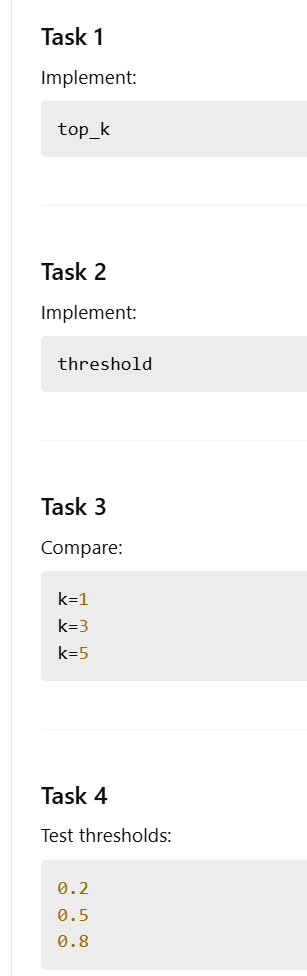

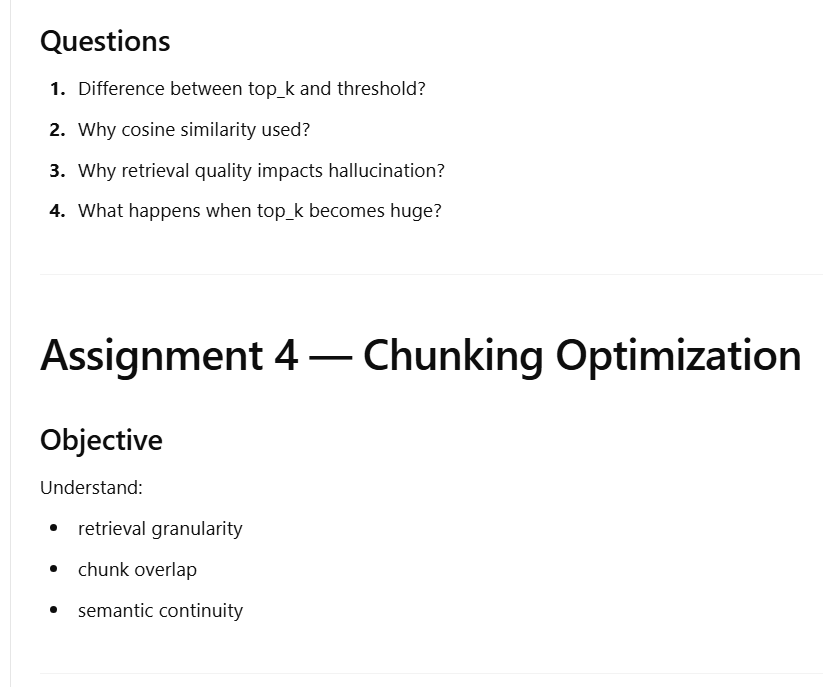

In [4]:
text = '''
Employees receive 20 annual paid leaves.
Employees must submit leave requests through the HR portal.
Health insurance covers employees and dependents.
Travel reimbursement is available for business trips.
Employees can work remotely twice a week.
Office cafeteria serves free lunch on Fridays.
Parking spaces are allocated quarterly.
Performance reviews occur every six months.
Internet expenses are reimbursed for remote employees.
'''

# -----------------------------
# CHUNKING PARAMETERS
# -----------------------------

chunk_size = 80
chunk_overlap = 20

chunks = []

start = 0

# -----------------------------
# OVERLAP CHUNKING
# -----------------------------

while start < len(text):

    end = start + chunk_size

    chunk = text[start:end]

    chunks.append(chunk)

    start += chunk_size - chunk_overlap

# -----------------------------
# OUTPUT
# -----------------------------

for idx, chunk in enumerate(chunks):

    print(f"\nChunk {idx+1}:\n")

    print(chunk)


Chunk 1:


Employees receive 20 annual paid leaves.
Employees must submit leave requests t

Chunk 2:

mit leave requests through the HR portal.
Health insurance covers employees and 

Chunk 3:

overs employees and dependents.
Travel reimbursement is available for business t

Chunk 4:

lable for business trips.
Employees can work remotely twice a week.
Office cafet

Chunk 5:

a week.
Office cafeteria serves free lunch on Fridays.
Parking spaces are alloca

Chunk 6:

ng spaces are allocated quarterly.
Performance reviews occur every six months.
I

Chunk 7:

 every six months.
Internet expenses are reimbursed for remote employees.


Chunk 8:

te employees.



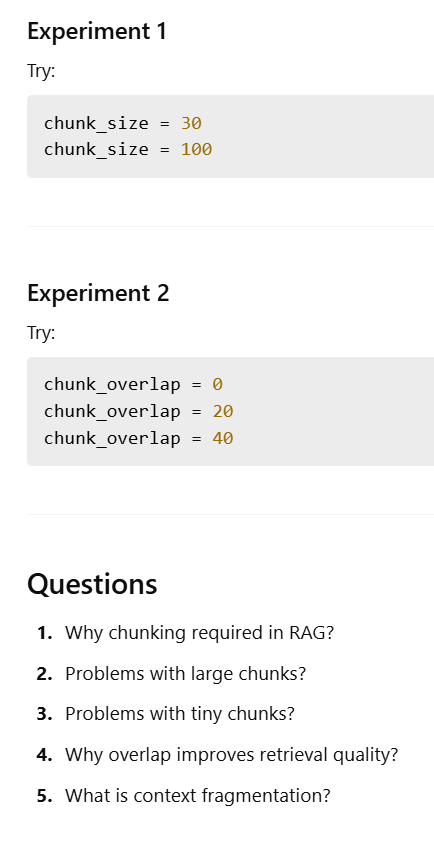

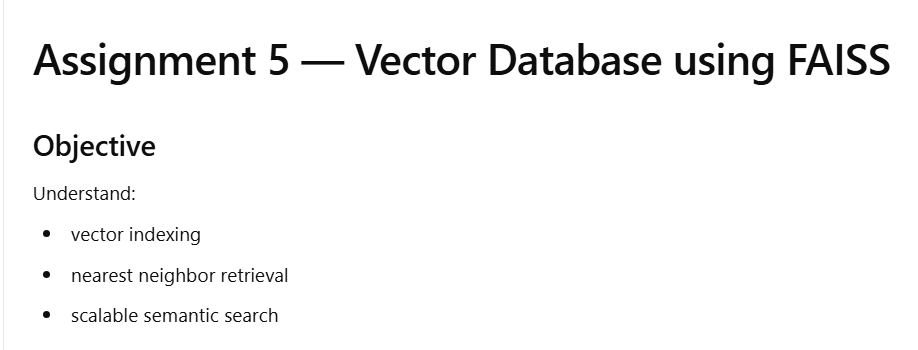

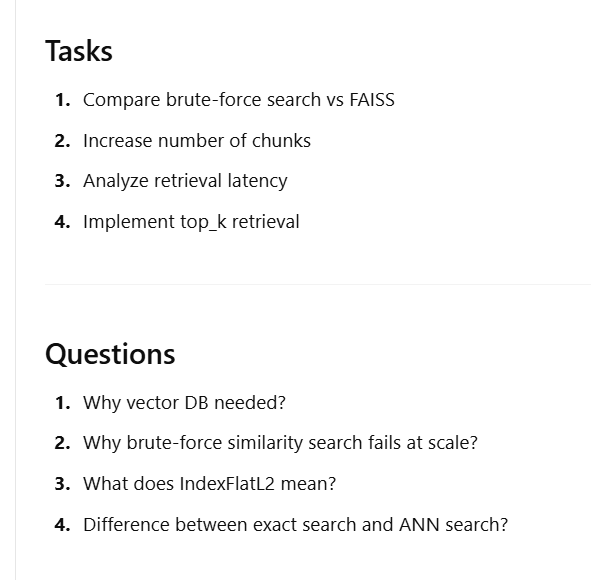

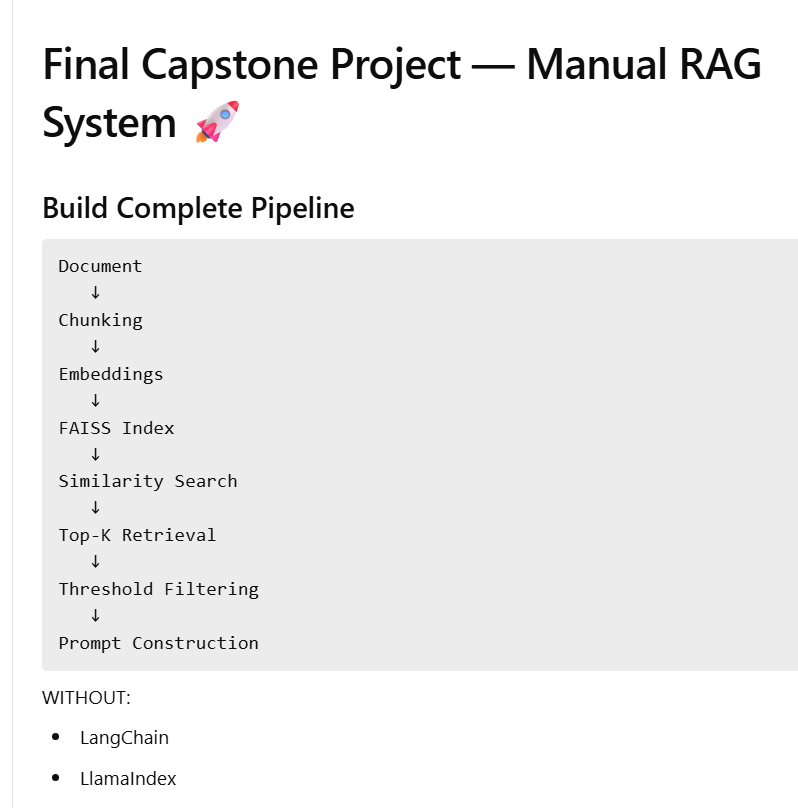

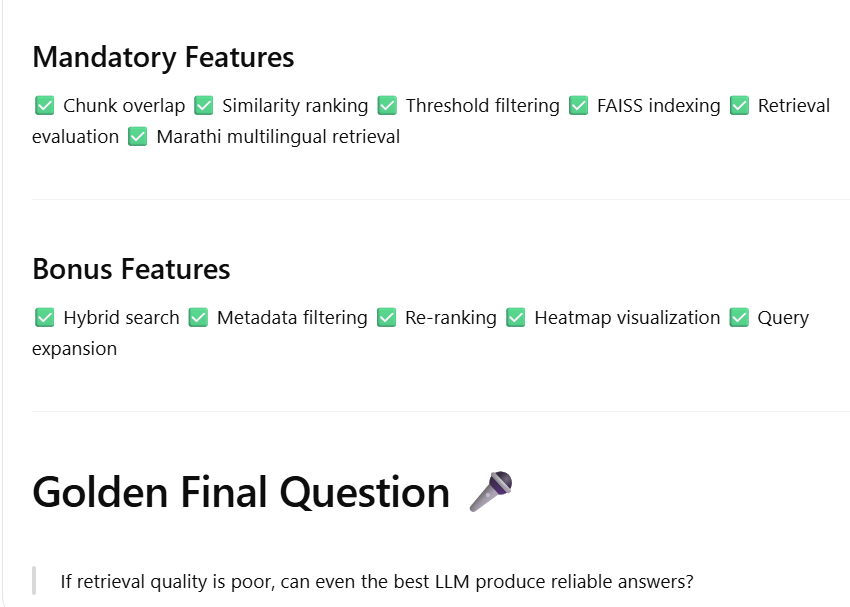